In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [3]:
# Load the processed master dataset
df = pd.read_csv(
    "../data/processed/master_sales_dataset.csv",
    parse_dates=[
        "order_purchase_timestamp",
        "order_delivered_customer_date"
    ]
)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (113425, 43)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_day,purchase_weekday,delivery_days,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,payment_count,review_score,review_count,review_comment_title,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,2,Monday,8.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0,housewares,9350.0,maua,SP,38.71,1.0,"credit_card, voucher",3.0,4.0,1.0,NaN,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,24,Tuesday,13.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0,perfumery,31570.0,belo horizonte,SP,141.46,1.0,boleto,1.0,4.0,1.0,Muito boa a loja,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,8,Wednesday,9.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0,auto,14840.0,guariba,SP,179.12,3.0,credit_card,1.0,5.0,1.0,NaN,NaN
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,18,Saturday,13.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0,pet_shop,31842.0,belo horizonte,MG,72.20,1.0,credit_card,1.0,5.0,1.0,NaN,O produto foi exatamente o que eu esperava e e...
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,13,Tuesday,2.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.0,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0,stationery,8752.0,mogi das cruzes,SP,28.62,1.0,credit_card,1.0,5.0,1.0,NaN,NaN


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113425 entries, 0 to 113424
Data columns (total 43 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113425 non-null  object        
 1   customer_id                    113425 non-null  object        
 2   order_status                   113425 non-null  object        
 3   order_purchase_timestamp       113425 non-null  datetime64[ns]
 4   order_approved_at              113264 non-null  object        
 5   order_delivered_carrier_date   111457 non-null  object        
 6   order_delivered_customer_date  110196 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113425 non-null  object        
 8   purchase_year                  113425 non-null  int64         
 9   purchase_month                 113425 non-null  int64         
 10  purchase_day                   113425 non-null  int64         
 11  

In [5]:
customer_features = (
    df.groupby("customer_id")
      .agg(
          total_orders=("order_id", "nunique"),
          total_spent=("payment_value", "sum"),
          avg_order_value=("payment_value", "mean"),
          avg_review_score=("review_score", "mean"),
          avg_delivery_days=("delivery_days", "mean"),
          first_purchase=("order_purchase_timestamp", "min"),
          last_purchase=("order_purchase_timestamp", "max")
      )
      .reset_index()
)

In [6]:
customer_features["customer_tenure_days"] = (
    customer_features["last_purchase"] -
    customer_features["first_purchase"]
).dt.days

In [7]:
customer_features["avg_review_score"] = (
    customer_features["avg_review_score"]
    .fillna(customer_features["avg_review_score"].median())
)

customer_features["avg_delivery_days"] = (
    customer_features["avg_delivery_days"]
    .fillna(customer_features["avg_delivery_days"].median())
)

In [8]:
print(customer_features.shape)

customer_features.head()

(99441, 9)


,customer_id,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,first_purchase,last_purchase,customer_tenure_days
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,114.74,1.0,13.0,2017-11-14 16:08:26,2017-11-14 16:08:26,0
1,000161a058600d5901f007fab4c27140,1,67.41,67.41,4.0,9.0,2017-07-16 09:40:32,2017-07-16 09:40:32,0
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,195.42,5.0,5.0,2017-02-28 11:06:43,2017-02-28 11:06:43,0
3,0002414f95344307404f0ace7a26f1d5,1,179.35,179.35,5.0,28.0,2017-08-16 13:09:20,2017-08-16 13:09:20,0
4,000379cdec625522490c315e70c7a9fb,1,107.01,107.01,4.0,11.0,2018-04-02 13:42:17,2018-04-02 13:42:17,0


In [9]:
customer_features.describe().T

,count,mean,min,25%,50%,75%,max,std
total_orders,99441.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0
total_spent,99441.0,205.858013,0.0,62.76,109.62,195.91,109312.64,619.118686
avg_order_value,99440.0,160.990267,0.0,62.01,105.29,176.97,13664.08,221.951257
avg_review_score,99441.0,4.093846,1.0,4.0,5.0,5.0,5.0,1.343446
avg_delivery_days,99441.0,12.031647,0.0,6.0,10.0,15.0,209.0,9.415006
first_purchase,99441,2017-12-31 08:43:12.776581120,2016-09-04 21:15:19,2017-09-12 14:46:19,2018-01-18 23:04:36,2018-05-04 15:42:16,2018-10-17 17:30:18,NaN
last_purchase,99441,2017-12-31 08:43:12.776581120,2016-09-04 21:15:19,2017-09-12 14:46:19,2018-01-18 23:04:36,2018-05-04 15:42:16,2018-10-17 17:30:18,NaN
customer_tenure_days,99441.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
customer_features.isnull().sum()

customer_id             0
total_orders            0
total_spent             0
avg_order_value         1
avg_review_score        0
avg_delivery_days       0
first_purchase          0
last_purchase           0
customer_tenure_days    0
dtype: int64

In [12]:
customer_features[customer_features["avg_order_value"].isna()]

,customer_id,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,first_purchase,last_purchase,customer_tenure_days
52277,86dc2ffce2dfff336de2f386a786e574,1,0.0,NaN,1.0,54.0,2016-09-15 12:16:38,2016-09-15 12:16:38,0


In [13]:
customer_features["avg_order_value"] = (
    customer_features["avg_order_value"]
    .fillna(customer_features["avg_order_value"].median())
)

In [14]:
customer_features.isnull().sum()

customer_id             0
total_orders            0
total_spent             0
avg_order_value         0
avg_review_score        0
avg_delivery_days       0
first_purchase          0
last_purchase           0
customer_tenure_days    0
dtype: int64

In [15]:
# Save customer features
customer_features.to_csv(
    "../data/processed/customer_features.csv",
    index=False
)

print("Customer features saved successfully!")

Customer features saved successfully!


In [17]:
customer_features = pd.read_csv(
    "../data/processed/customer_features.csv",
    parse_dates=["first_purchase", "last_purchase"]
)

In [18]:
features = [
    "total_orders",
    "total_spent",
    "avg_order_value",
    "avg_review_score",
    "avg_delivery_days",
    "customer_tenure_days"
]

X = customer_features[features]

X.head()

,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,customer_tenure_days
0,1,114.74,114.74,1.0,13.0,0
1,1,67.41,67.41,4.0,9.0,0
2,1,195.42,195.42,5.0,5.0,0
3,1,179.35,179.35,5.0,28.0,0
4,1,107.01,107.01,4.0,11.0,0


In [19]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_orders          99441 non-null  int64  
 1   total_spent           99441 non-null  float64
 2   avg_order_value       99441 non-null  float64
 3   avg_review_score      99441 non-null  float64
 4   avg_delivery_days     99441 non-null  float64
 5   customer_tenure_days  99441 non-null  int64  
dtypes: float64(4), int64(2)
memory usage: 4.6 MB


In [20]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
total_orders,99441.0,1.000000,0.000000,1.0,1.00,1.00,1.00,1.00
total_spent,99441.0,205.858013,619.118686,0.0,62.76,109.62,195.91,109312.64
avg_order_value,99441.0,160.989707,221.950211,0.0,62.01,105.29,176.97,13664.08
avg_review_score,99441.0,4.093846,1.343446,1.0,4.00,5.00,5.00,5.00
avg_delivery_days,99441.0,12.031647,9.415006,0.0,6.00,10.00,15.00,209.00
customer_tenure_days,99441.0,0.000000,0.000000,0.0,0.00,0.00,0.00,0.00


In [21]:
X.isnull().sum()

total_orders            0
total_spent             0
avg_order_value         0
avg_review_score        0
avg_delivery_days       0
customer_tenure_days    0
dtype: int64

In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [23]:
X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

X_scaled.head()

,total_orders,total_spent,avg_order_value,avg_review_score,avg_delivery_days,customer_tenure_days
0,0.0,-0.147174,-0.208380,-2.302930,0.102853,0.0
1,0.0,-0.223622,-0.421627,-0.069855,-0.322003,0.0
2,0.0,-0.016860,0.155127,0.674503,-0.746859,0.0
3,0.0,-0.042816,0.082723,0.674503,1.696062,0.0
4,0.0,-0.159660,-0.243208,-0.069855,-0.109575,0.0


In [24]:
print(X_scaled.mean())

print("-" * 50)

print(X_scaled.std())

total_orders            0.000000e+00
total_spent            -3.358324e-18
avg_order_value        -1.279021e-16
avg_review_score        8.124286e-17
avg_delivery_days      -5.496576e-17
customer_tenure_days    0.000000e+00
dtype: float64
--------------------------------------------------
total_orders            0.000000
total_spent             1.000005
avg_order_value         1.000005
avg_review_score        1.000005
avg_delivery_days       1.000005
customer_tenure_days    0.000000
dtype: float64


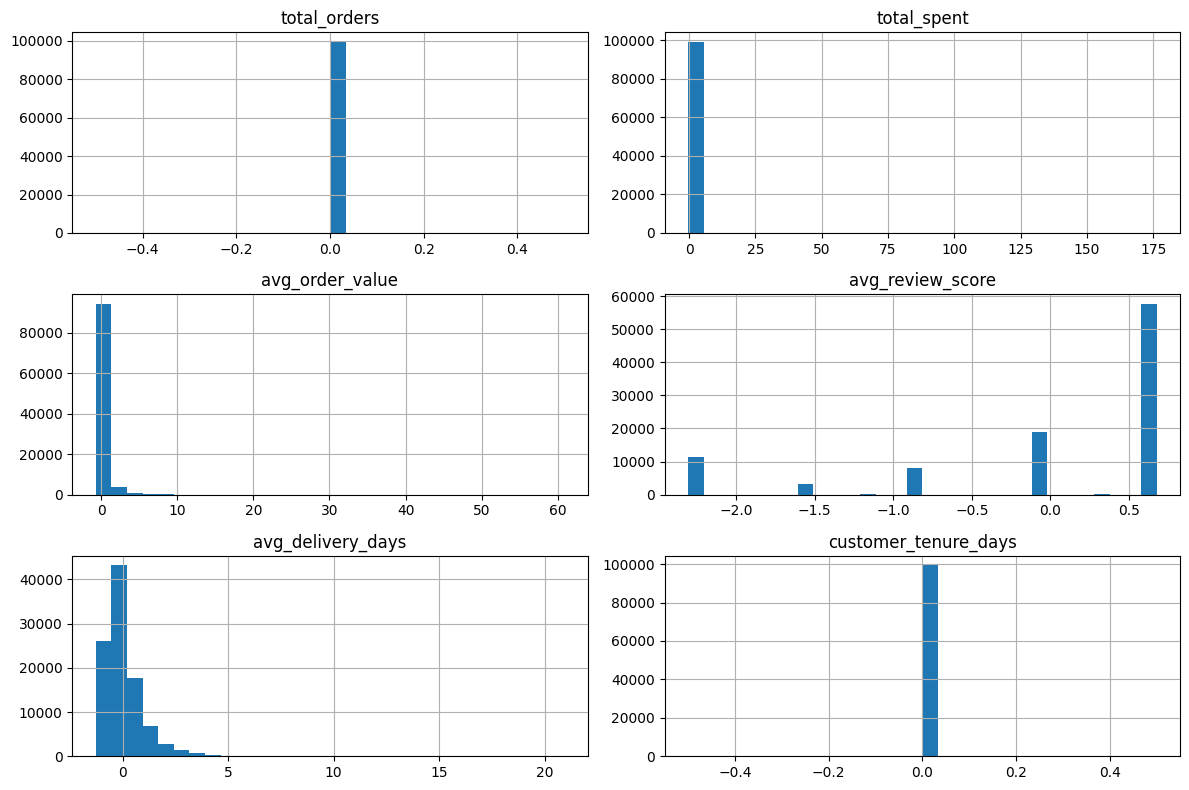

In [25]:
X_scaled.hist(
    figsize=(12, 8),
    bins=30
)

plt.tight_layout()
plt.show()

In [27]:
inertia = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/clus

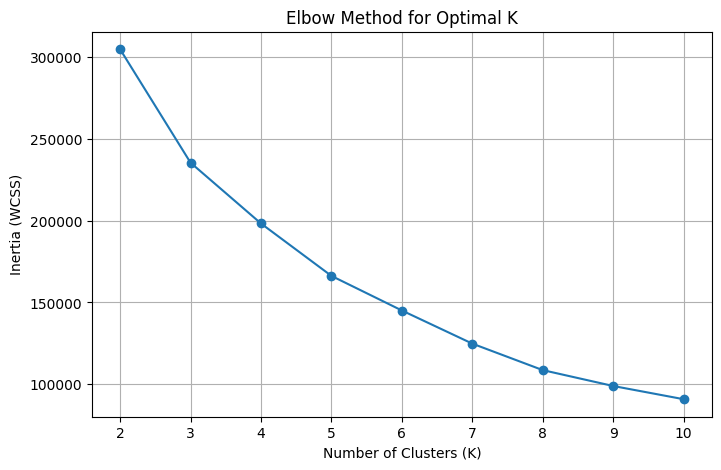

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (WCSS)")
plt.grid(True)

plt.show()

In [29]:
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/rohithjavvadi/realsalesanalytics/.venv/lib/python3.9/site-packages/sklearn/clus

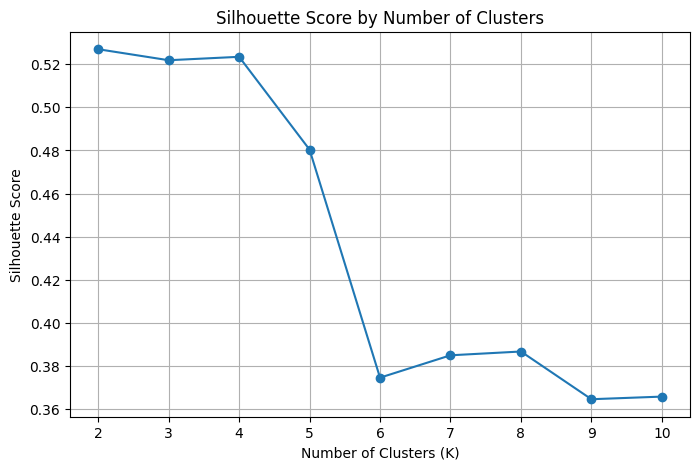

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)

plt.show()

In [31]:
evaluation = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertia,
    "Silhouette Score": silhouette_scores
})

evaluation

,K,Inertia,Silhouette Score
0,2,304688.626674,0.526935
1,3,235386.740256,0.521831
2,4,198254.990772,0.523416
3,5,166235.151072,0.480363
4,6,145105.534581,0.374616
5,7,124861.083088,0.384989
6,8,108686.105741,0.386744
7,9,98987.352495,0.364616
8,10,90920.675213,0.365830


In [32]:
evaluation.sort_values(
    by="Silhouette Score",
    ascending=False
)

,K,Inertia,Silhouette Score
0,2,304688.626674,0.526935
2,4,198254.990772,0.523416
1,3,235386.740256,0.521831
3,5,166235.151072,0.480363
6,8,108686.105741,0.386744
5,7,124861.083088,0.384989
4,6,145105.534581,0.374616
8,10,90920.675213,0.365830
7,9,98987.352495,0.364616
